### Install libraries

In [28]:
pip install pandas matplotlib seaborn scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Import Ddta set

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("E:/new pro/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Data Cleaning

In [8]:
df = df[df['CustomerID'].notna()]
df = df[df['Quantity'] > 0]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

#### Feature Engineering

In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [11]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')


In [12]:
customer_df = df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID', 'TotalRevenue', 'TotalOrders', 'TotalQuantity']

### Create Business Segments

In [25]:
customer_df['Segment'] = pd.qcut(customer_df['TotalRevenue'], 3, labels=['Low', 'Medium', 'High'])

### Add Risk Logic

In [26]:
customer_df['Risk'] = customer_df['TotalOrders'].apply(
    lambda x: 'High Risk' if x < 3 else 'Low Risk'
)

### revenue distribution

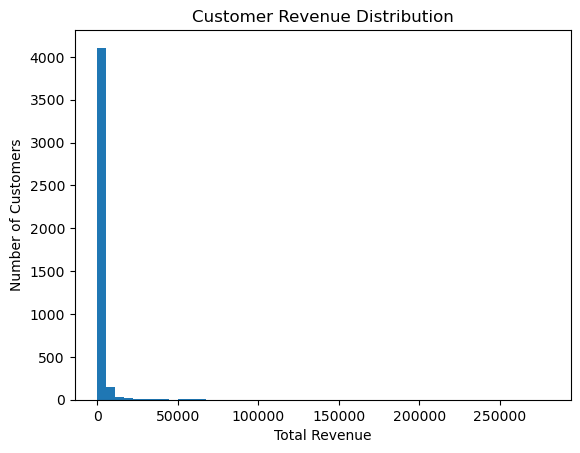

In [17]:
plt.figure()
plt.hist(customer_df['TotalRevenue'], bins=50)
plt.title("Customer Revenue Distribution")
plt.xlabel("Total Revenue")
plt.ylabel("Number of Customers")
plt.show()

### segment counts

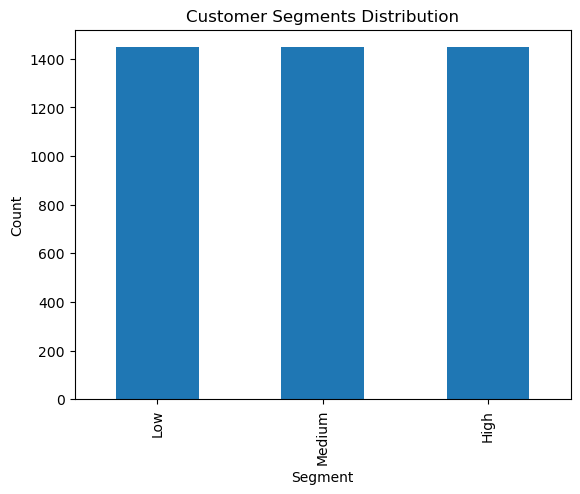

In [18]:
plt.figure()
customer_df['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

In [20]:
print(customer_df.columns)

Index(['CustomerID', 'TotalRevenue', 'TotalOrders', 'TotalQuantity',
       'Segment'],
      dtype='object')


### risk vs revenue

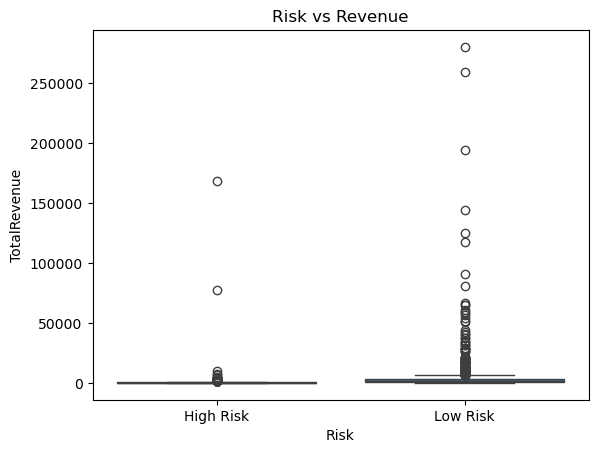

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x='Risk', y='TotalRevenue', data=customer_df)
plt.title("Risk vs Revenue")
plt.show()

### Top 10 Customers

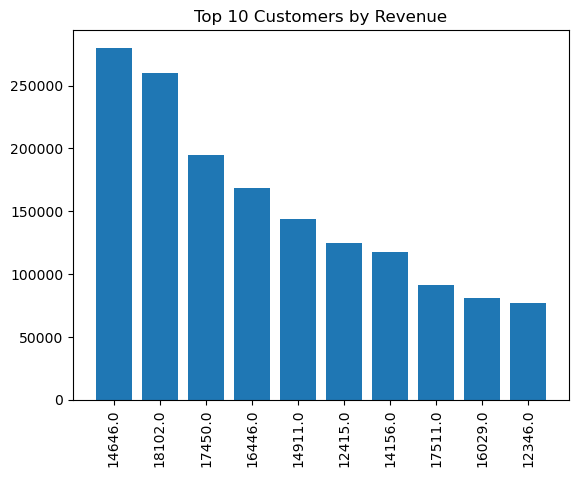

In [23]:
top_customers = customer_df.sort_values(by='TotalRevenue', ascending=False).head(10)

plt.figure()
plt.bar(top_customers['CustomerID'].astype(str), top_customers['TotalRevenue'])
plt.title("Top 10 Customers by Revenue")
plt.xticks(rotation=90)
plt.show()

### Orders vs Revenue

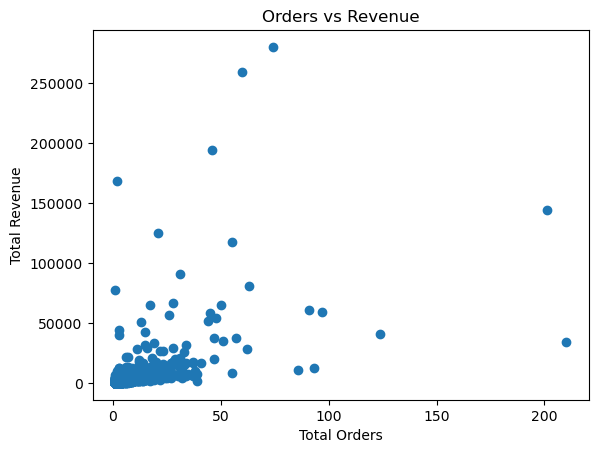

In [24]:
plt.figure()
plt.scatter(customer_df['TotalOrders'], customer_df['TotalRevenue'])
plt.title("Orders vs Revenue")
plt.xlabel("Total Orders")
plt.ylabel("Total Revenue")
plt.show()

BUSINESS INSIGHTS

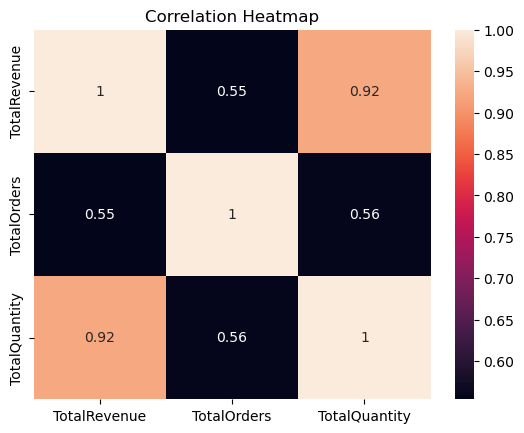

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(customer_df[['TotalRevenue','TotalOrders','TotalQuantity']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Business Insights - Business Portfolio Risk Analysis

### Dataset Summary
- Online retail transaction data analyzed
- Features: InvoiceNo, CustomerID, Country, Quantity, UnitPrice
- Engineered features: Revenue, TotalOrders, TotalQuantity, Segment, Risk

### Key Findings

1. Revenue Distribution is Highly Skewed
   - Most customers generate small revenue
   - A small group of high-value customers drive most of the total revenue
   - This is a classic 80/20 pattern in retail business

2. Customer Segments
   - Low Segment: Customers with lowest total spending
   - Medium Segment: Average spenders, largest group
   - High Segment: Top spenders, most valuable to business

3. Risk Analysis
   - High Risk customers: placed fewer than 3 orders total
   - These customers have low engagement and high churn probability
   - Low Risk customers: placed 3 or more orders, more loyal

4. Top 10 Customers
   - Top 10 customers contribute disproportionately to total revenue
   - Losing even one top customer significantly impacts business revenue
   - These customers should receive premium retention treatment

5. Orders vs Revenue Relationship
   - Positive correlation between total orders and total revenue
   - Customers who order more tend to spend more overall
   - Encouraging repeat purchases is key to revenue growth
   

### Business Recommendations
1. Focus retention efforts on High Risk customers with fewer than 3 orders
   by offering discount coupons or loyalty rewards on their next purchase
2. Protect top 10 customers with dedicated account management and
   exclusive offers to prevent churn
3. Convert Medium segment customers to High segment through
   targeted upselling campaigns
4. Customers in Low segment should receive re-engagement emails
   to increase their order frequency

### Model Used
- Rule-based segmentation using Revenue quartiles (qcut)
- Risk classification based on order frequency threshold